# Analysis of the cleaned data and creation of sub-stations for analysis 

L'idée de ce notebook et d'ajouter autant de features que nécessaire au dataset complet pour l'analyse de données : variables binaires qui indique si le point est dans la ZTL, autour, à l'intersection d'une autoroute, si oui laquelle, si le point de donnée a été enregistré avant ou après la mise en place de la ZTL.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import folium
from folium.plugins import MarkerCluster
import geopandas as gpd
from geopy.distance import geodesic

import requests
import json

from shapely.geometry import Point, shape
from shapely.ops import unary_union
from geopy.distance import geodesic # Pour un calcul précis en mètres

import seaborn as sns

In [ ]:
file_path = '/Users/quentingirard/Downloads/MCNDU_simple_clean_full_dataset - only bad datapoints cleaned.csv'

try:
    full_df_clean = pd.read_csv(file_path, sep=';', encoding='utf-8')
    
    full_df_clean['Datetime'] = pd.to_datetime(full_df_clean['Datetime'])
    
    print("✅ Importation réussie !")
    print(f"Dimensions : {full_df_clean.shape[0]} lignes, {full_df_clean.shape[1]} colonnes.")
    display(full_df_clean.head())

except Exception as e:
    print(f"❌ Erreur lors de l'importation : {e}")

✅ Importation réussie !
Dimensions : 12203672 lignes, 15 colonnes.


,Occupation,Debit,Arc Name,Arc ID,Datetime,End Date Available Data,Start Date Available Data,ID Upstream Node,Trafic,ID Downstream Node,Upstream Node Name,Arc State,Downstream Node Name,Latitude,Longitude
0,3.14333,425.0,Bd_Poniatowski,6997,2026-01-05 15:00:00+00:00,2023-01-01,2016-09-15,3627,Fluide,565,Poniatowski-Baron-Leroy,1.0,Bd_Poniatowski-Pte_Charenton,48.831201,2.396694
1,6.77778,569.0,Bd_Malesherbes,239,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,144,Fluide,146,Bd_Malesherbes-Chauveau_Lagarde,1.0,Bd_Malesherbes-Boissy_d'Anglas,48.871119,2.322386
2,2.77555,153.0,Bd_Jourdan,726,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,416,Fluide,422,Pl_25_Aout_1944-Av_Gal_Leclerc,1.0,Bd_Jourdan-Pere_Corentin,48.822973,2.326119
3,4.45778,598.0,Bd_Brune,724,2026-01-05 15:00:00+00:00,2019-06-01,2005-01-01,411,Fluide,412,Pl_Pte_Chatillon,1.0,Bd_Brune-Av_Pte_Montrouge,48.823857,2.322154
4,4.43278,598.0,Bd_Brune,723,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,407,Fluide,411,Bd_Brune-Plantes,1.0,Pl_Pte_Chatillon,48.824657,2.318709


## Adding features to datapoints

### Adding the arrondissement

In [ ]:
url_geojson = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/arrondissements/exports/geojson?lang=fr&timezone=Europe%2FParis"
geo_data_all = requests.get(url_geojson).json()

arrondissements_shapes = {}
for feature in geo_data_all['features']:
    code_arr = feature['properties']['c_ar']
    arrondissements_shapes[code_arr] = shape(feature['geometry'])

print(f"✅ Géométrie chargée pour {len(arrondissements_shapes)} arrondissements.")


print("Identification des stations uniques...")
unique_stations = full_df_clean[['Latitude', 'Longitude']].drop_duplicates().copy()

def get_arrondissement(row):
    point = Point(row['Longitude'], row['Latitude'])
    
    for code, polygon in arrondissements_shapes.items():
        if polygon.contains(point):
            return code
    return None 

print(f"Calcul de l'arrondissement pour {len(unique_stations)} stations...")
unique_stations['Arrondissement'] = unique_stations.apply(get_arrondissement, axis=1)


print("Fusion avec le dataset principal...")
full_df_clean = full_df_clean.merge(
    unique_stations,
    on=['Latitude', 'Longitude'],
    how='left'
)

full_df_clean['Arrondissement'] = full_df_clean['Arrondissement'].astype('Int64')

print("-" * 30)
print("✅ Colonne 'Arrondissement' ajoutée avec succès.")
print("Aperçu des 5 premières lignes :")
display(full_df_clean[['Arc Name', 'Latitude', 'Longitude', 'Arrondissement']].head())

nb_sans_arr = full_df_clean['Arrondissement'].isna().sum()
pct_sans_arr = (nb_sans_arr / len(full_df_clean)) * 100
print(f"\nDiagnostic : {nb_sans_arr} lignes ({pct_sans_arr:.1f}%) sont hors des arrondissements 1-20 (probablement le Périphérique).")

✅ Géométrie chargée pour 20 arrondissements.
Identification des stations uniques...
Calcul de l'arrondissement pour 1751 stations...
Fusion avec le dataset principal...
------------------------------
✅ Colonne 'Arrondissement' ajoutée avec succès.
Aperçu des 5 premières lignes :


,Arc Name,Latitude,Longitude,Arrondissement
0,Bd_Poniatowski,48.831201,2.396694,12
1,Bd_Malesherbes,48.871119,2.322386,8
2,Bd_Jourdan,48.822973,2.326119,14
3,Bd_Brune,48.823857,2.322154,14
4,Bd_Brune,48.824657,2.318709,14



Diagnostic : 95759 lignes (0.8%) sont hors des arrondissements 1-20 (probablement le Périphérique).


On check que les points sans arrondissement sont effectivement sur le périphérique (pas de pb structurel avec notre code)

In [ ]:
df_missing = full_df_clean[full_df_clean['Arrondissement'].isna()]

missing_stations = df_missing.groupby(['Latitude', 'Longitude']).size().reset_index(name='volume')

print(f"Analyse des points hors zone :")
print(f"Nombre de lignes concernées : {len(df_missing)}")
print(f"Nombre de stations uniques concernées : {len(missing_stations)}")

print("Affichage de la carte avec les points sans arrondissement")


m_debug = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')

folium.GeoJson(
    geo_data_all,
    name="Arrondissements",
    style_function=lambda x: {
        'color': '#3498db',      # Bleu
        'weight': 2,
        'fillOpacity': 0.1
    }
).add_to(m_debug)

for index, row in missing_stations.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=1.0,
        popup=f"<b>Station Hors Zone</b><br>Lat/Lon: {row['Latitude']:.4f}, {row['Longitude']:.4f}<br>Volume: {row['volume']}",
        tooltip="Station Hors Arrondissement"
    ).add_to(m_debug)

m_debug

Analyse des points hors zone :
Nombre de lignes concernées : 95759
Nombre de stations uniques concernées : 13
Affichage de la carte avec les points sans arrondissement


Les points sans arrondissement sont sur le Périphérique : **ce n'est pas un problème pour notre analyse car on utilise ce mapping pour savoir si le point est ou non à l'intérieur de la ZTL**.

### Adding the columns in_ZTL and near_ZTL

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
url_geojson = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/arrondissements/exports/geojson?lang=fr&timezone=Europe%2FParis"
response = requests.get(url_geojson)
geo_data = response.json()

# Filtrage pour ne garder que les arr 1, 2, 3 et 4
paris_centre_features = [
    feature for feature in geo_data['features'] 
    if feature['properties']['c_ar'] in [1, 2, 3, 4]
]

paris_centre_geojson = {
    "type": "FeatureCollection",
    "features": paris_centre_features
}
# création du buffer

print("Génération de la géométrie de l'anneau (500m)...")
distance_buffer_meters = 500

gdf_ztl = gpd.GeoDataFrame.from_features(paris_centre_features)
gdf_ztl = gdf_ztl.set_crs(epsg=4326)

gdf_ztl_union = gdf_ztl.dissolve()
gdf_buffer = gdf_ztl_union.to_crs(epsg=2154).buffer(distance_buffer_meters).to_crs(epsg=4326)

gdf_ring = gdf_buffer.difference(gdf_ztl_union)

ring_geometry = gdf_ring.unary_union


print("Identification des stations uniques pour le calcul...")
unique_stations = full_df_clean[['Latitude', 'Longitude']].drop_duplicates().copy()

def check_near_ztl(lat, lon):
    point = Point(lon, lat)
    return 1 if ring_geometry.contains(point) else 0

print(f"Calcul de la position 'near_ZTL' pour {len(unique_stations)} stations...")
unique_stations['near_ZTL'] = unique_stations.apply(
    lambda row: check_near_ztl(row['Latitude'], row['Longitude']), 
    axis=1
)


print("Fusion des indicateurs avec le dataset principal...")

full_df_clean = full_df_clean.merge(
    unique_stations[['Latitude', 'Longitude', 'near_ZTL']],
    on=['Latitude', 'Longitude'],
    how='left'
)

full_df_clean['in_ZTL'] = full_df_clean['Arrondissement'].isin([1, 2, 3, 4]).astype(int)


full_df_clean['near_ZTL'] = full_df_clean['near_ZTL'].fillna(0).astype(int)

print("-" * 30)
print("✅ Colonnes ajoutées avec succès.")
print(f"Lignes dans la ZTL (in_ZTL=1)      : {full_df_clean['in_ZTL'].sum()}")
print(f"Lignes proches ZTL (near_ZTL=1)    : {full_df_clean['near_ZTL'].sum()}")

overlap = len(full_df_clean[(full_df_clean['in_ZTL'] == 1) & (full_df_clean['near_ZTL'] == 1)])
print(f"Points classés à la fois dedans et autour (doit être 0) : {overlap}")

print("\nAperçu :")
display(full_df_clean[['Arc Name', 'Arrondissement', 'in_ZTL', 'near_ZTL']].sample(5))

Génération de la géométrie de l'anneau (500m)...
Identification des stations uniques pour le calcul...


/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_2457/2001550443.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ring_geometry = gdf_ring.unary_union


Calcul de la position 'near_ZTL' pour 1751 stations...
Fusion des indicateurs avec le dataset principal...
------------------------------
✅ Colonnes ajoutées avec succès.
Lignes dans la ZTL (in_ZTL=1)      : 815898
Lignes proches ZTL (near_ZTL=1)    : 1227529
Points classés à la fois dedans et autour (doit être 0) : 0

Aperçu :


,Arc Name,Arrondissement,in_ZTL,near_ZTL
10980371,Av_Pdt_Kennedy,16,0,0
11892984,Quai_Branly,7,0,0
4509381,Tolbiac,13,0,0
7221541,PI_Muette,16,0,0
2772835,Bd_Haussmann,8,0,0


In [ ]:
# Mapping des points dans et autour de la ZTL

print("Agrégation des données par station...")

station_stats = full_df_clean.groupby(['Latitude', 'Longitude', 'in_ZTL', 'near_ZTL']).size().reset_index(name='volume')

df_in = station_stats[station_stats['in_ZTL'] == 1]

df_near = station_stats[station_stats['near_ZTL'] == 1]

print(f"Stations à tracer dans la ZTL : {len(df_in)}")
print(f"Stations à tracer autour (Buffer) : {len(df_near)}")


# Map creation

m_final = folium.Map(location=[48.8566, 2.3522], zoom_start=13, tiles='CartoDB positron')

# ZTL
folium.GeoJson(
    paris_centre_geojson,
    name="Zone ZTL",
    style_function=lambda x: {'color': '#FFD700', 'fillColor': '#FFD700', 'fillOpacity': 0.1, 'weight': 2}
).add_to(m_final)

# Anneau 
try:
    folium.GeoJson(
        gdf_ring,
        name="Zone Tampon",
        style_function=lambda x: {'color': '#C71585', 'fillColor': '#FF1493', 'fillOpacity': 0.1, 'weight': 2}
    ).add_to(m_final)


# plotting points

def get_radius(volume):
    r = volume / 5000
    if r < 4: return 4
    if r > 15: return 15
    return r

# points dans la ZTL
for idx, row in df_in.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=get_radius(row['volume']),
        color='#FF4500', 
        fill=True,
        fill_color='#FF4500',
        fill_opacity=0.8,  
        popup=f"<b>ZTL (Intérieur)</b><br>Vol: {row['volume']}",
        tooltip="Station ZTL"
    ).add_to(m_final)

# points dans le buffer
for idx, row in df_near.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=get_radius(row['volume']),
        color='#8A2BE2', 
        fill=True,
        fill_color='#8A2BE2',
        fill_opacity=0.8,
        popup=f"<b>Zone Tampon</b><br>Vol: {row['volume']}",
        tooltip="Station Buffer"
    ).add_to(m_final)

m_final

Agrégation des données par station...
Stations à tracer dans la ZTL : 118
Stations à tracer autour (Buffer) : 180


### Adding six columns : one for each highway insertion on the Boulevard Periphérique

In [ ]:
# ADDING THE SIX COLMUNS FOR DISTANCE TO HIGHWAY ENTRANCES


dist_highway_threshold = 400  # Distance en mètres (ex: 1000 = 1km)

autoroutes_coords = {
    'A1 (Porte de la Chapelle)': [48.9004, 2.3596],
    'A3 (Porte de Bagnolet)': [48.8687, 2.4105],
    'A4 (Porte de Bercy)': [48.8324, 2.3861],
    'A6a (Porte d\'Orléans)': [48.8208, 2.3259],
    'A6b (Porte d\'Italie)': [48.8159, 2.3603],
    'A13 (Porte d\'Auteuil)': [48.8465, 2.2547]
}


future_cols = [f"near_{k.split(' ')[0]}" for k in autoroutes_coords.keys()]
cols_to_drop = [c for c in future_cols if c in full_df_clean.columns]

if cols_to_drop:
    print(f"🔄 Suppression des anciennes colonnes {cols_to_drop}...")
    full_df_clean = full_df_clean.drop(columns=cols_to_drop)
else:
    print("✨ Calcul initial.")


print(f"Calcul des distances aux portes (Seuil : {dist_highway_threshold}m)...")
unique_stations = full_df_clean[['Latitude', 'Longitude']].drop_duplicates().copy()

def is_near_point(row_lat, row_lon, target_lat, target_lon, threshold):
    if geodesic((row_lat, row_lon), (target_lat, target_lon)).meters < threshold:
        return 1
    return 0

for name, coords in autoroutes_coords.items():
    short_name = name.split(' ')[0]
    col_name = f"near_{short_name}"
    target_lat, target_lon = coords
    
    unique_stations[col_name] = unique_stations.apply(
        lambda row: is_near_point(row['Latitude'], row['Longitude'], target_lat, target_lon, dist_highway_threshold),
        axis=1
    )


print("Fusion avec le dataset complet...")
cols_to_merge = ['Latitude', 'Longitude'] + future_cols

full_df_clean = full_df_clean.merge(
    unique_stations[cols_to_merge],
    on=['Latitude', 'Longitude'],
    how='left'
)

print("-" * 30)
print(f"✅ Recalcul terminé avec seuil = {dist_highway_threshold}m.")
print("Nombre de STATIONS DE COMPTAGE uniques détectées par porte :")

total_stations_near = 0

for col in future_cols:
    nb_stations = unique_stations[col].sum()
    if nb_stations > 0:
        print(f" - {col.replace('near_', '')} : {nb_stations} stations")
        total_stations_near += nb_stations

print(f"\nAu total, {total_stations_near} stations sont situées à moins de {dist_highway_threshold}m d'une porte.")

🔄 Suppression des anciennes colonnes ['near_A1', 'near_A3', 'near_A4', 'near_A6a', 'near_A6b', 'near_A13']...
Calcul des distances aux portes (Seuil : 400m)...
Fusion avec le dataset complet...
------------------------------
✅ Recalcul terminé avec seuil = 400m.
Nombre de STATIONS DE COMPTAGE uniques détectées par porte :
 - A1 : 9 stations
 - A3 : 7 stations
 - A4 : 12 stations
 - A6a : 13 stations
 - A6b : 14 stations
 - A13 : 13 stations

Au total, 68 stations sont situées à moins de 400m d'une porte.


In [ ]:
# vérification par mapping


print("Préparation des données pour la carte...")

cols_near = [col for col in full_df_clean.columns if col.startswith('near_A')]
unique_stations = full_df_clean[['Latitude', 'Longitude'] + cols_near].drop_duplicates()
stations_concernees = unique_stations[unique_stations[cols_near].sum(axis=1) > 0]

print(f"Nombre de stations identifiées 'proches autoroute' à afficher : {len(stations_concernees)}")

m_highways = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')

# affichage des autoroutes
for name, coords in autoroutes_coords.items():
    folium.CircleMarker(
        location=coords,
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=1.0,
        popup=f"<b>{name}</b><br>Point de référence",
        tooltip=name
    ).add_to(m_highways)
    
    folium.Circle(
        location=coords,
        radius=dist_highway_threshold,
        color='#3498db',  
        fill=True,
        fill_color='#3498db',
        fill_opacity=0.2,  
        tooltip=f"Zone de {dist_highway_threshold}m"
    ).add_to(m_highways)


# stations proches des points d'insertion
for idx, row in stations_concernees.iterrows():
    autoroutes_proches = [col.replace('near_', '') for col in cols_near if row[col] == 1]
    info_bulle = ", ".join(autoroutes_proches)
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4,
        color='red', 
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        popup=f"<b>Station de comptage</b><br>Captée par : {info_bulle}",
        tooltip=f"Proche {info_bulle}"
    ).add_to(m_highways)

m_highways

Préparation des données pour la carte...
Nombre de stations identifiées 'proches autoroute' à afficher : 68


### Affichage de toutes les stations d'intérêt

In [ ]:
# Affichage de la map finale 

print("Préparation des couches de données...")

cols_highway = [c for c in full_df_clean.columns if c.startswith('near_A')]

agg_dict = {
    'in_ZTL': 'max', 
    'near_ZTL': 'max',
    'Arc Name': 'size' # Pour le volume
}
for col in cols_highway:
    agg_dict[col] = 'max'

stations_stats = full_df_clean.groupby(['Latitude', 'Longitude']).agg(agg_dict).reset_index()
stations_stats.rename(columns={'Arc Name': 'volume'}, inplace=True)

df_ztl_pts = stations_stats[stations_stats['in_ZTL'] == 1]
df_ring_pts = stations_stats[stations_stats['near_ZTL'] == 1]
df_highway_pts = stations_stats[stations_stats[cols_highway].sum(axis=1) > 0]

print(f" - Stations ZTL : {len(df_ztl_pts)}")
print(f" - Stations Anneau : {len(df_ring_pts)}")
print(f" - Stations Autoroutes : {len(df_highway_pts)}")


m_global = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')


# zones géographiques

# ZTL
folium.GeoJson(
    paris_centre_geojson,
    name="Zone : ZTL (Centre)",
    style_function=lambda x: {
        'color': '#FFD700',       # Contour Jaune
        'fillColor': '#FFD700',   # Remplissage Jaune
        'weight': 2,
        'fillOpacity': 0.15
    }
).add_to(m_global)

# Buffer
try:
    folium.GeoJson(
        gdf_ring,
        name="Zone : Tampon ZTL",
        style_function=lambda x: {
            'color': '#FF1493',       # Contour Rose foncé
            'fillColor': '#FF69B4',   # Remplissage Rose
            'weight': 2,
            'fillOpacity': 0.15
        }
    ).add_to(m_global)
except NameError:
    print("⚠️ Attention : l'objet gdf_ring n'est pas en mémoire.")

# Autoroutes
fg_zones_highway = folium.FeatureGroup(name="Zones : Autoroutes")

for name, coords in autoroutes_coords.items():
    folium.Circle(
        location=coords,
        radius=dist_highway_threshold,
        color='#3498db',      # Bleu
        fill=True,
        fill_color='#3498db',
        fill_opacity=0.15,
        weight=1,
        tooltip=f"Zone {name}"
    ).add_to(fg_zones_highway)
    
fg_zones_highway.add_to(m_global)


# Datapoints

def get_radius(vol):
    r = vol / 5000
    return max(3, min(r, 10))

# dans la ZTL
fg_pts_ztl = folium.FeatureGroup(name="Points : ZTL (Orange)")
for _, row in df_ztl_pts.iterrows():
    folium.CircleMarker(
        [row['Latitude'], row['Longitude']],
        radius=get_radius(row['volume']),
        color='#FF4500', fill=True, fill_color='#FF4500', fill_opacity=0.8,
        tooltip=f"ZTL: {row['volume']} pts"
    ).add_to(fg_pts_ztl)
fg_pts_ztl.add_to(m_global)

# dans le buffer
fg_pts_ring = folium.FeatureGroup(name="Points : Anneau (Violet)")
for _, row in df_ring_pts.iterrows():
    folium.CircleMarker(
        [row['Latitude'], row['Longitude']],
        radius=get_radius(row['volume']),
        color='#8A2BE2', fill=True, fill_color='#8A2BE2', fill_opacity=0.8,
        tooltip=f"Ring: {row['volume']} pts"
    ).add_to(fg_pts_ring)
fg_pts_ring.add_to(m_global)

# près des autoroutes
fg_pts_highway = folium.FeatureGroup(name="Points : Autoroutes (Rouge)")
for _, row in df_highway_pts.iterrows():
    infos = [c.replace('near_', '') for c in cols_highway if row[c] == 1]
    
    folium.CircleMarker(
        [row['Latitude'], row['Longitude']],
        radius=get_radius(row['volume']),
        color='#DC143C', fill=True, fill_color='#DC143C', fill_opacity=0.8, # Rouge cramoisi
        tooltip=f"Porte {'/'.join(infos)}: {row['volume']} pts"
    ).add_to(fg_pts_highway)
fg_pts_highway.add_to(m_global)

folium.LayerControl(position='topright', collapsed=False).add_to(m_global)

m_global

Préparation des couches de données...
 - Stations ZTL : 118
 - Stations Anneau : 180
 - Stations Autoroutes : 68


## Checking if data is usable

--- TABLEAU RÉCAPITULATIF DES VOLUMES DE DONNÉES ---


,Nombre de Datapoints,% du Total
near_ZTL,1227529,10.06
in_ZTL,815898,6.69
near_A6b,116356,0.95
near_A6a,110141,0.90
near_A13,99121,0.81
near_A3,64635,0.53
near_A4,60235,0.49
near_A1,58541,0.48


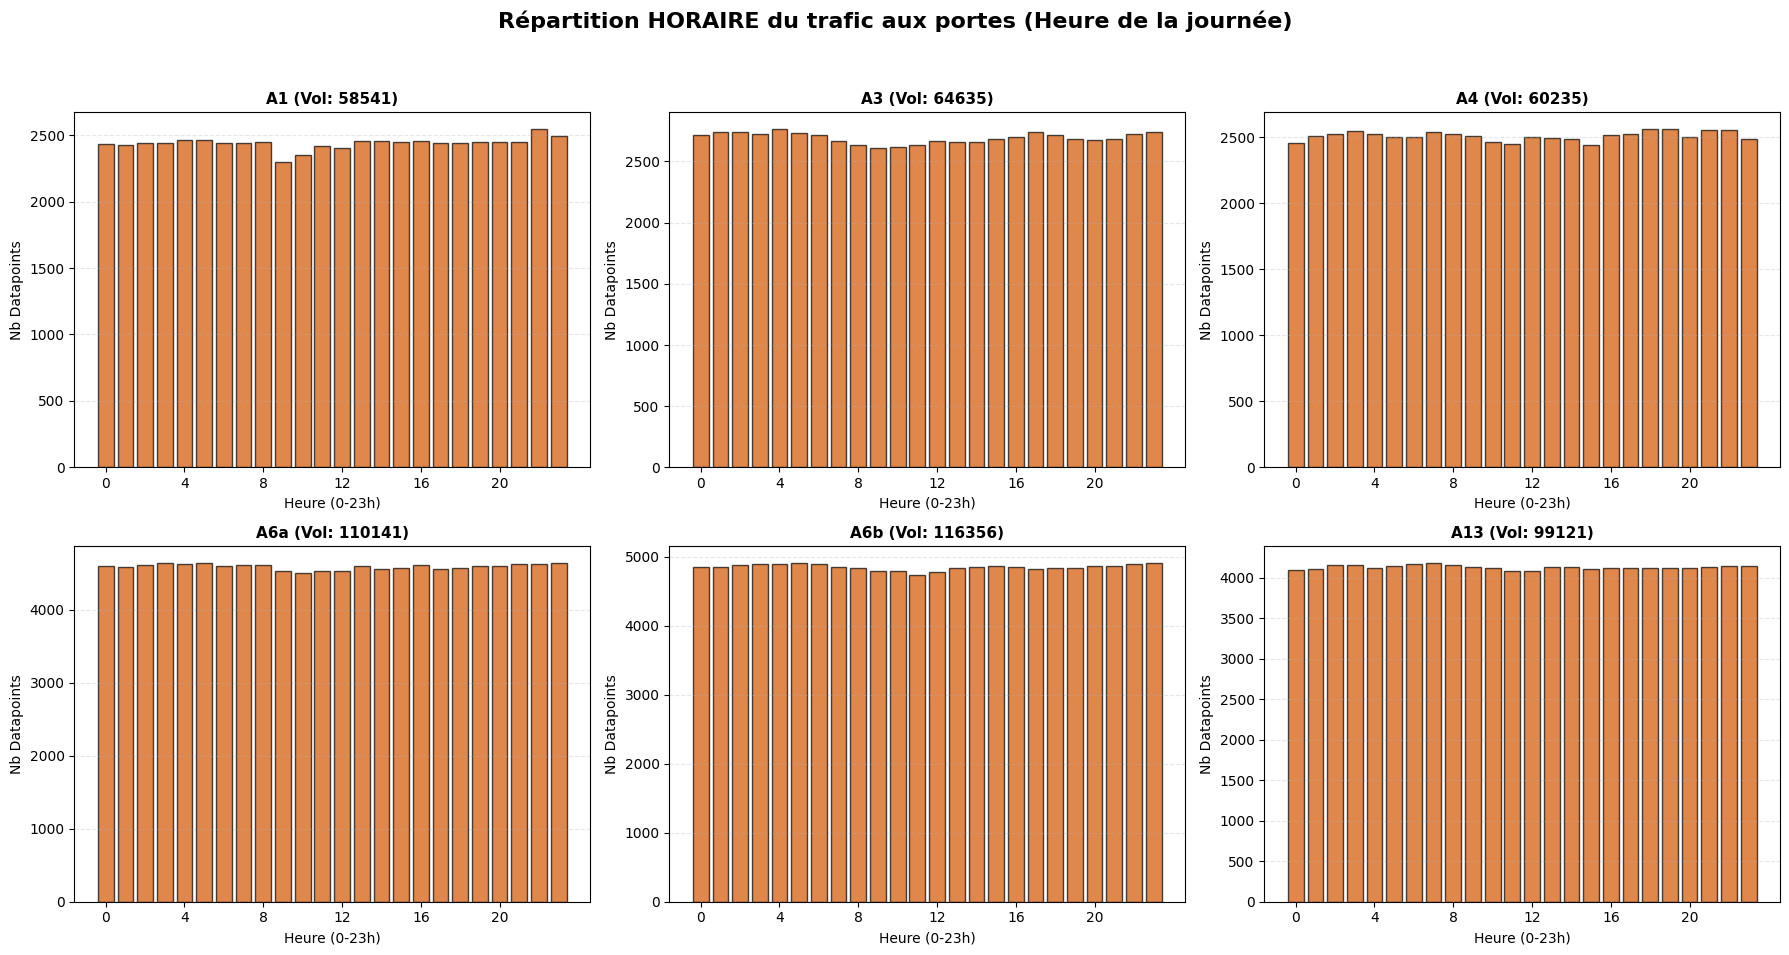

/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_2457/2044976871.py:67: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  counts = subset['Datetime'].dt.to_period('M').value_counts().sort_index()
/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_2457/2044976871.py:67: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  counts = subset['Datetime'].dt.to_period('M').value_counts().sort_index()
/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_2457/2044976871.py:67: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  counts = subset['Datetime'].dt.to_period('M').value_counts().sort_index()
/var/folders/gl/j4h6g1555f7669vb8m7321jc0000gn/T/ipykernel_2457/2044976871.py:67: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  counts = subset['Datetime'].dt.to_period('M').value_counts().sort_index()


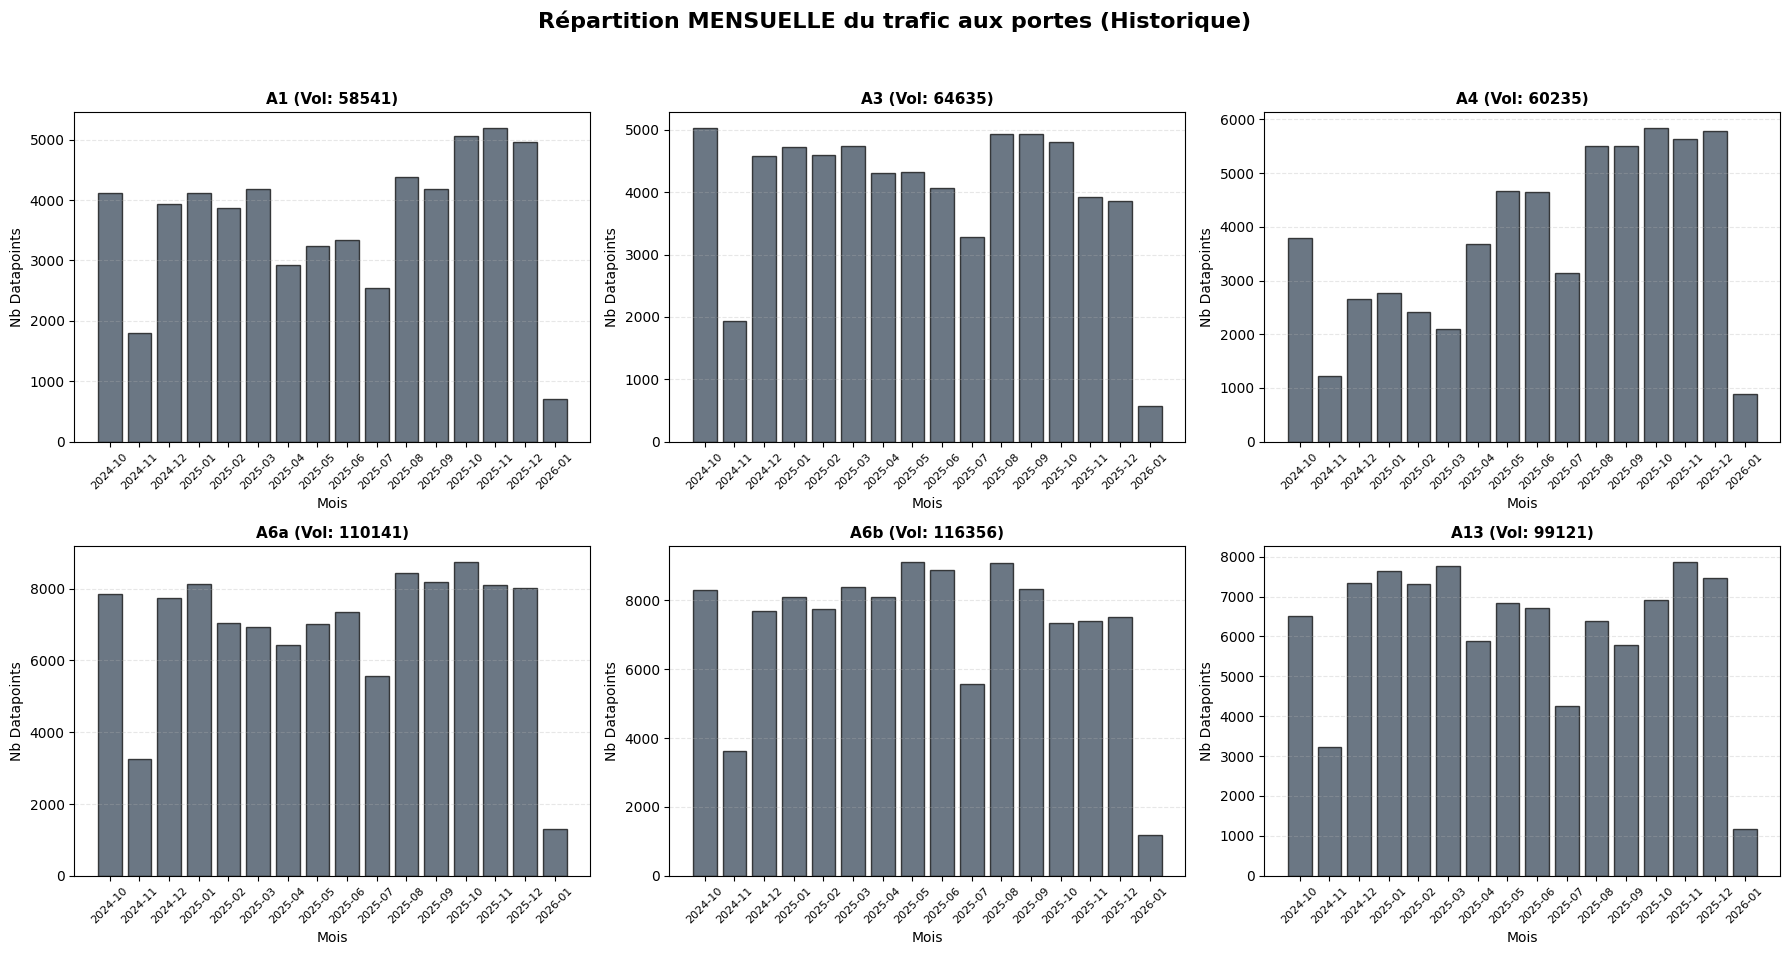

In [ ]:
#TEMPOREL VISUALISATIONS AND SUMMARY TABLES


print("--- TABLEAU RÉCAPITULATIF DES VOLUMES DE DONNÉES ---")

cols_highway = [c for c in full_df_clean.columns if c.startswith('near_A')]
zones_interet = ['in_ZTL', 'near_ZTL'] + cols_highway

volumes = full_df_clean[zones_interet].sum().sort_values(ascending=False)

df_summary = pd.DataFrame(volumes, columns=['Nombre de Datapoints'])
df_summary['% du Total'] = (df_summary['Nombre de Datapoints'] / len(full_df_clean) * 100).round(2)

display(df_summary)


# histogrammes

def plot_highway_distributions(time_component='hour'):
    """
    Trace les histogrammes pour chaque autoroute.
    time_component: 'hour' ou 'month'
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    if time_component == 'hour':
        main_title = "Répartition HORAIRE du trafic aux portes (Heure de la journée)"
        xlabel = "Heure (0-23h)"
        color = '#d35400'
    else:
        main_title = "Répartition MENSUELLE du trafic aux portes (Historique)"
        xlabel = "Mois"
        color = '#2c3e50'

    fig.suptitle(main_title, fontsize=16, fontweight='bold')

    for i, col_name in enumerate(cols_highway):
        ax = axes[i]
        
        subset = full_df_clean[full_df_clean[col_name] == 1]
        
        if subset.empty:
            ax.text(0.5, 0.5, "Pas de données", ha='center')
            continue

        if time_component == 'hour':
            counts = subset['Datetime'].dt.hour.value_counts().sort_index()
            counts = counts.reindex(range(24), fill_value=0)
            
            ax.bar(counts.index, counts.values, color=color, alpha=0.7, edgecolor='black')
            ax.set_xticks(range(0, 24, 4)) # Ticks toutes les 4h pour lisibilité
            
        elif time_component == 'month':
            counts = subset['Datetime'].dt.to_period('M').value_counts().sort_index()
            
            ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.7, edgecolor='black')
            ax.tick_params(axis='x', rotation=45, labelsize=8)

        nom_porte = col_name.replace('near_', '')
        vol_total = len(subset)
        ax.set_title(f"{nom_porte} (Vol: {vol_total})", fontsize=11, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Nb Datapoints")
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# A. Histogrammes par heure (0-23h)
plot_highway_distributions(time_component='hour')

# B. Histogrammes par mois (Chronologie)
plot_highway_distributions(time_component='month')

In [ ]:
# CLEANING DATASET TO KEEP ONLY STUDIED POINTS

highway_cols = [col for col in full_df_clean.columns if col.startswith('near_A')]

def print_poi_stats(df, step_name):
    n_in_ztl = df['in_ZTL'].sum()
    n_near_ztl = df['near_ZTL'].sum()
    n_near_highway = df[highway_cols].any(axis=1).sum()
    
    print(f"--- {step_name} ---")
    print(f"Total lignes      : {len(df)}")
    print(f"Points in_ZTL     : {n_in_ztl}")
    print(f"Points near_ZTL   : {n_near_ztl}")
    print(f"Points near_Autoroute : {n_near_highway}")
    print("-" * 30)

print_poi_stats(full_df_clean, "AVANT LE FILTRE")

mask_poi = (
    full_df_clean['in_ZTL'] | 
    full_df_clean['near_ZTL'] | 
    full_df_clean[highway_cols].any(axis=1)
)

full_df_clean = full_df_clean[mask_poi].copy()

print_poi_stats(full_df_clean, "APRÈS LE FILTRE")
print(f"\nNombre de lignes supprimées (bruit) : {len(mask_poi) - mask_poi.sum()}")

--- AVANT LE FILTRE ---
Total lignes      : 12203672
Points in_ZTL     : 815898
Points near_ZTL   : 1227529
Points near_Autoroute : 509029
------------------------------
--- APRÈS LE FILTRE ---
Total lignes      : 2552456
Points in_ZTL     : 815898
Points near_ZTL   : 1227529
Points near_Autoroute : 509029
------------------------------

Nombre de lignes supprimées (bruit) : 9651216


## Filtrage temporel pour les ZTL

On veut séparer les points de la ZTL et autour de la ZTL en fonction de si la mesure a été faite avant ou après le début de l'application des Zones à Traffic Limité (5 novembre 2024)

In [ ]:
ztl_start_date = pd.Timestamp('2024-11-05', tz='UTC')

full_df_clean['ZTL_enforced'] = full_df_clean['Datetime'] >= ztl_start_date

stats = full_df_clean.groupby('ZTL_enforced')[['in_ZTL', 'near_ZTL']].sum()

print("--- Comparaison Avant (False) / Après (True) la mise en place de la ZTL ---")
display(stats)

--- Comparaison Avant (False) / Après (True) la mise en place de la ZTL ---


,in_ZTL,near_ZTL
ZTL_enforced,,
False,52914,84803
True,762984,1142726


## Export of the dataset

In [ ]:
output_path = '/Users/quentingirard/Downloads/MCNDU_final_dataset.csv'
full_df_clean.to_csv(output_path, index=False, sep=';', encoding='utf-8')

print(f"✅ Dataset exporté avec succès ici : {output_path}")

✅ Dataset exporté avec succès ici : /Users/quentingirard/Downloads/MCNDU_final_dataset.csv
